## Keras Custom callbacks

### Custom callbacks - Visualize predictions (Prepare a GIF)

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import datetime
import io

from PIL import Image
from IPython.display import Image as IPyImage
import imageio

In [2]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(60000, 784).astype('float32') / 255
x_test = x_test.reshape(10000, 784).astype('float32') / 255

In [3]:
# Create a model for training and getting predictions
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(32, activation='linear', input_dim=784),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


/Users/opmule/miniforge3/envs/ai_tensorflow/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-24 21:39:08.298639: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-02-24 21:39:08.298788: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-24 21:39:08.298823: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1771949348.299276 3641692 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1771949348.299484 3641692 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:

## An overview of callback methods


### Common methods for training/testing/predicting
For training, testing, and predicting, following methods are provided to be overridden.<br>
1. `on_(train|test|predict)_begin(self, logs=None)`<br>
Called at the beginning of `fit`/`evaluate`/`predict`.<br><br>
2. `on_(train|test|predict)_end(self, logs=None)`<br>
Called at the end of `fit`/`evaluate`/`predict`.<br><br>
3. `on_(train|test|predict)_batch_begin(self, batch, logs=None)`<br>
Called right before processing a batch during training/testing/predicting. Within this method, `logs` is a dict with `batch` and `size` available keys, representing the current batch number and the size of the batch.<br><br>
4. `on_(train|test|predict)_batch_end(self, batch, logs=None)` <br>
Called at the end of training/testing/predicting a batch. Within this method, `logs` is a dict containing the stateful metrics result.<br>
<br>

### Training specific methods
In addition, for training, following are provided. <br>
1. `on_epoch_begin(self, epoch, logs=None)` <br>
Called at the beginning of an epoch during training. <br><br>
2. `on_epoch_end(self, epoch, logs=None)` <br>
Called at the end of an epoch during training.


### Visualization utilities

In [4]:
GIF_path = './predictions_animation.gif'

In [5]:
# Visualization utilities
plt.rc('font', size=20)
plt.rc('figure', figsize=(15,3))

def display_digits(inputs, outputs, ground_truth, epoch, n=10):
    plt.clf()

    plt.yticks([])
    plt.grid(None)
    # Create images of (28 x 28)
    inputs = np.reshape(inputs, [n, 28, 28])
    # swaps axes to line images side by side
    inputs = np.swapaxes(inputs, 0, 1)
    # Create a single long horizontal image of 10 images
    inputs = np.reshape(inputs, [28, 28*n])
    plt.imshow(inputs)

    # Places the predicted label below each image & color codes the prediction
    plt.xticks([28*x+14 for x in range(n)], outputs)
    for i,t in enumerate(plt.gca().xaxis.get_ticklabels()):
        if outputs[i] == ground_truth[i]:
            t.set_color('green')
        else:
            t.set_color('red')
    plt.grid(None)

### Visualization Callback

In [8]:
class VisCallback(tf.keras.callbacks.Callback):
    def __init__(self, inputs, ground_truth, display_freq=10, n_samples=10):
        self.inputs = inputs
        self.ground_truth = ground_truth
        self.images = []
        self.display_freq = display_freq
        self.n_samples = n_samples

    def on_epoch_end(self, epoch, logs=None):
        # Randomly sample data
        indexes = np.random.choice(len(self.inputs), size=self.n_samples)
        x_test, y_test = self.inputs[indexes], self.ground_truth[indexes]
        predictions = np.argmax(self.model.predict(x_test), axis=1)

        # Plot digits
        display_digits(x_test, predictions, y_test, epoch, n=self.n_samples)

        # Save the figure
        buf = io.BytesIO()
        plt.savefig(buf, format='png')
        buf.seek(0)
        image = Image.open(buf)
        self.images.append(np.array(image))

        # Display the digits every 'display_freq' number of epochs
        if epoch % self.display_freq == 0:
            plt.show()

    # Save the GIF file
    def on_train_end(self, logs=None):
        imageio.mimsave(GIF_path, self.images, fps=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


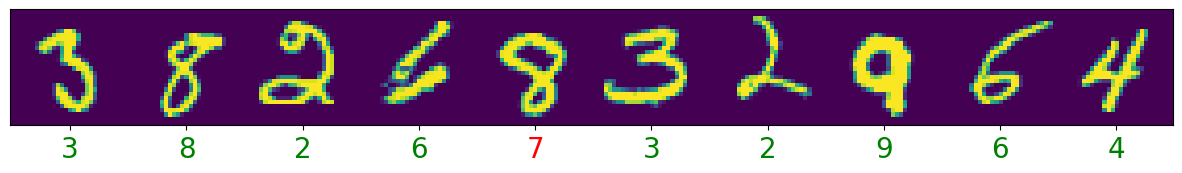

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


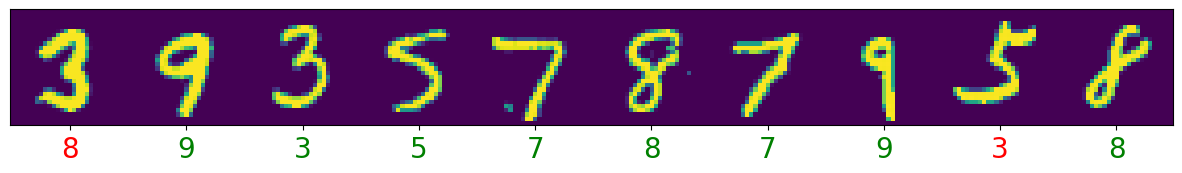

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


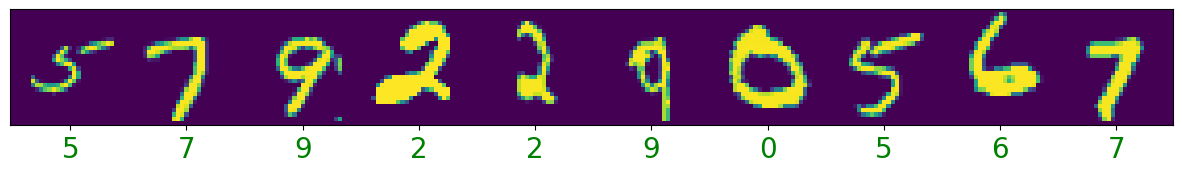

In [9]:
model.fit(x_train, y_train, batch_size=64, epochs=20, verbose=0, callbacks=[VisCallback(x_test, y_test)])

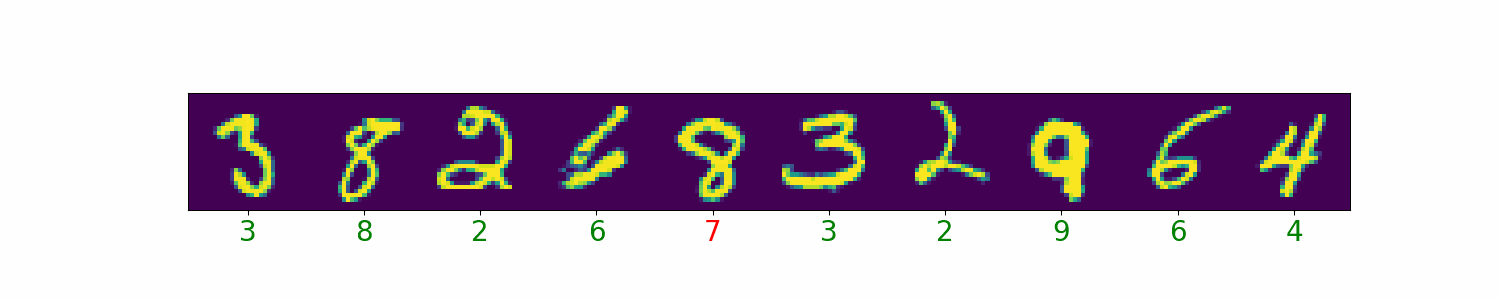

In [12]:
Scale = 60
IPyImage(GIF_path, format='png', width=15 * Scale, height=3 * Scale)